#Notebook 05 — Final KPI Computation & Data Load Preparation
**Dataset:** Road Traffic Accidents (RTA)  
**Input:** `cleaned_rta.csv` (output of `02_cleaning.ipynb`)  
**Goal:** Compute KPIs, build final analytics-ready table, and save for downstream use

---
## 0. Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os
from datetime import datetime

# ── Output directory ───────────────────────────────────────────────────────────
os.makedirs('data/final', exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})

SEVERITY_ORDER  = ['slight injury', 'serious injury', 'fatal injury']
SEVERITY_COLORS = {'slight injury': '#4CAF50', 'serious injury': '#FF9800', 'fatal injury': '#F44336'}
PALETTE         = ['#4CAF50', '#FF9800', '#F44336']

LOAD_TIMESTAMP  = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
PIPELINE_VER    = 'v1.0'
print('Setup complete. Load timestamp:', LOAD_TIMESTAMP)

Setup complete. Load timestamp: 2026-04-21 14:37:11


---
## 1. Load Cleaned Data

In [ ]:
df = pd.read_csv('/content/cleaned_dataset.csv')

# Normalise column names (in case notebook 02 output has mixed casing)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nMissing values:\n', df.isnull().sum()[df.isnull().sum() > 0].to_string() or 'None ✓')
df.head(3)

Shape: (12295, 22)
Columns: ['accident_severity', 'number_of_casualties', 'time', 'day_of_week', 'area_accident_occured', 'types_of_junction', 'road_allignment', 'lanes_or_medians', 'weather_conditions', 'light_conditions', 'road_surface_conditions', 'type_of_collision', 'vehicle_movement', 'cause_of_accident', 'age_band_of_driver', 'driving_experience', 'sex_of_driver', 'type_of_vehicle', 'hour', 'time_period', 'severity_score', 'is_weekend']

Missing values:
 Series([], )


,accident_severity,number_of_casualties,time,day_of_week,area_accident_occured,types_of_junction,road_allignment,lanes_or_medians,weather_conditions,light_conditions,...,vehicle_movement,cause_of_accident,age_band_of_driver,driving_experience,sex_of_driver,type_of_vehicle,hour,time_period,severity_score,is_weekend
0,slight injury,2,1900-01-01 17:02:00,monday,residential areas,no junction,tangent road with flat terrain,two-way (divided with broken lines road marking),normal,daylight,...,going straight,moving backward,18-30,1-2yr,male,automobile,17,afternoon,1,False
1,slight injury,2,1900-01-01 17:02:00,monday,office areas,no junction,tangent road with flat terrain,undivided two way,normal,daylight,...,going straight,overtaking,31-50,above 10yr,male,public (> 45 seats),17,afternoon,1,False
2,serious injury,2,1900-01-01 17:02:00,monday,recreational areas,no junction,tangent road with flat terrain,other,normal,daylight,...,going straight,changing lane to the left,18-30,1-2yr,male,lorry (41?100q),17,afternoon,2,False


In [ ]:
# Sanity check — severity must exist
assert 'accident_severity' in df.columns, "Missing 'accident_severity' column!"
assert df['accident_severity'].notna().all(), "Target column has nulls — check cleaning step!"

# Ensure severity_score exists (mapped in notebook 02)
if 'severity_score' not in df.columns:
    severity_map = {'slight injury': 1, 'serious injury': 2, 'fatal injury': 3}
    df['severity_score'] = df['accident_severity'].str.strip().str.lower().map(severity_map)

# Ensure time_period exists
if 'time_period' not in df.columns:
    def time_period(hour):
        if 6 <= hour < 12:   return 'morning'
        elif 12 <= hour < 18: return 'afternoon'
        elif 18 <= hour < 24: return 'evening'
        else:                 return 'night'
    df['time_period'] = df['hour'].apply(time_period)

# Ensure is_weekend exists
if 'is_weekend' not in df.columns:
    weekend_days = ['saturday', 'sunday']
    df['is_weekend'] = df['day_name'].str.lower().isin(weekend_days).astype(int)

print('All pre-checks passed ✓')

All pre-checks passed ✓


---
## 2. Compute KPIs

KPIs are grouped into 4 categories:
- **Volumetric** — record counts
- **Data Quality** — cleaning results
- **Severity** — accident severity breakdown
- **Operational** — business-level insights

### 2.1 Volumetric KPIs

In [ ]:
total_records     = len(df)
total_columns     = len(df.columns)
total_casualties  = int(df['number_of_casualties'].sum())
avg_casualties    = round(df['number_of_casualties'].mean(), 4)
median_casualties = round(df['number_of_casualties'].median(), 4)
max_casualties    = int(df['number_of_casualties'].max())

print(f'Total Records      : {total_records:,}')
print(f'Total Columns      : {total_columns}')
print(f'Total Casualties   : {total_casualties:,}')
print(f'Avg Casualties/Acc : {avg_casualties}')
print(f'Median Casualties  : {median_casualties}')
print(f'Max Casualties     : {max_casualties}')

Total Records      : 12,295
Total Columns      : 22
Total Casualties   : 19,035
Avg Casualties/Acc : 1.5482
Median Casualties  : 1.0
Max Casualties     : 8


### 2.2 Data Quality KPIs

In [ ]:
# These are derived from notebook 02 processing
# Original dataset had 12,316 rows before cleaning
ORIGINAL_ROW_COUNT = 12316

rows_after_cleaning  = total_records
rows_removed         = ORIGINAL_ROW_COUNT - rows_after_cleaning
pct_rows_retained    = round(rows_after_cleaning / ORIGINAL_ROW_COUNT * 100, 2)
null_count_remaining = int(df.isnull().sum().sum())
pct_null_free        = round((1 - null_count_remaining / (total_records * total_columns)) * 100, 4)
duplicate_count      = int(df.duplicated().sum())

print(f'Original Rows      : {ORIGINAL_ROW_COUNT:,}')
print(f'Rows After Cleaning: {rows_after_cleaning:,}')
print(f'Rows Removed       : {rows_removed:,}')
print(f'Pct Rows Retained  : {pct_rows_retained}%')
print(f'Remaining Nulls    : {null_count_remaining}')
print(f'Pct Null-Free Cells: {pct_null_free}%')
print(f'Duplicate Rows     : {duplicate_count}')

Original Rows      : 12,316
Rows After Cleaning: 12,295
Rows Removed       : 21
Pct Rows Retained  : 99.83%
Remaining Nulls    : 0
Pct Null-Free Cells: 100.0%
Duplicate Rows     : 0


### 2.3 Severity KPIs

In [ ]:
sev_counts = df['accident_severity'].str.lower().value_counts()

slight_count  = int(sev_counts.get('slight injury', 0))
serious_count = int(sev_counts.get('serious injury', 0))
fatal_count   = int(sev_counts.get('fatal injury', 0))

slight_pct    = round(slight_count  / total_records * 100, 2)
serious_pct   = round(serious_count / total_records * 100, 2)
fatal_pct     = round(fatal_count   / total_records * 100, 2)

avg_severity_score  = round(df['severity_score'].mean(), 4)
severe_accident_rate = round((serious_count + fatal_count) / total_records * 100, 2)  # serious+fatal

print(f'Slight Injuries : {slight_count:,}  ({slight_pct}%)')
print(f'Serious Injuries: {serious_count:,}  ({serious_pct}%)')
print(f'Fatal Injuries  : {fatal_count:,}   ({fatal_pct}%)')
print(f'Avg Severity Score     : {avg_severity_score}  (scale 1–3)')
print(f'Severe Accident Rate   : {severe_accident_rate}%  (serious + fatal)')

Slight Injuries : 10,400  (84.59%)
Serious Injuries: 1,737  (14.13%)
Fatal Injuries  : 158   (1.29%)
Avg Severity Score     : 1.167  (scale 1–3)
Severe Accident Rate   : 15.41%  (serious + fatal)


### 2.4 Operational / Business KPIs

In [ ]:
# ── Peak hour (most accidents) ─────────────────────────────────────────────────
peak_hour = int(df['hour'].value_counts().idxmax())

# ── Peak time period ───────────────────────────────────────────────────────────
peak_time_period = df['time_period'].value_counts().idxmax()

# ── Weekend vs weekday fatal rate ──────────────────────────────────────────────
def fatal_rate(subset):
    return round((subset['accident_severity'].str.lower() == 'fatal injury').mean() * 100, 2)

weekend_fatal_rate = fatal_rate(df[df['is_weekend'] == 1])
weekday_fatal_rate = fatal_rate(df[df['is_weekend'] == 0])
weekend_vs_weekday_ratio = round(weekend_fatal_rate / weekday_fatal_rate, 2) if weekday_fatal_rate else None

# ── Night accident severe rate ─────────────────────────────────────────────────
night_df = df[df['time_period'] == 'night']
night_severe_rate = round(
    (night_df['accident_severity'].str.lower().isin(['serious injury','fatal injury'])).mean() * 100, 2
)

# ── Top cause of accident ──────────────────────────────────────────────────────
top_cause = df['cause_of_accident'].value_counts().idxmax()
top_cause_count = int(df['cause_of_accident'].value_counts().iloc[0])
top_cause_pct = round(top_cause_count / total_records * 100, 2)

# ── Top collision type ─────────────────────────────────────────────────────────
top_collision = df['type_of_collision'].value_counts().idxmax()
top_collision_pct = round(df['type_of_collision'].value_counts().iloc[0] / total_records * 100, 2)

# ── Dominant driver age band ───────────────────────────────────────────────────
top_age_band = df['age_band_of_driver'].value_counts().idxmax()
top_age_band_pct = round(df['age_band_of_driver'].value_counts().iloc[0] / total_records * 100, 2)

# ── Male driver share ──────────────────────────────────────────────────────────
male_driver_pct = round((df['sex_of_driver'].str.lower() == 'male').mean() * 100, 2)

# ── Accidents in normal weather ────────────────────────────────────────────────
normal_weather_pct = round(
    (df['weather_conditions'].str.lower() == 'normal').mean() * 100, 2
)

# ── Accidents in daylight ──────────────────────────────────────────────────────
daylight_pct = round(
    (df['light_conditions'].str.lower() == 'daylight').mean() * 100, 2
)

print(f'Peak Hour                  : {peak_hour}:00')
print(f'Peak Time Period           : {peak_time_period}')
print(f'Weekend Fatal Rate         : {weekend_fatal_rate}%')
print(f'Weekday Fatal Rate         : {weekday_fatal_rate}%')
print(f'Weekend/Weekday Ratio      : {weekend_vs_weekday_ratio}x')
print(f'Night Severe Rate          : {night_severe_rate}%')
print(f'Top Cause                  : {top_cause} ({top_cause_pct}%)')
print(f'Top Collision Type         : {top_collision} ({top_collision_pct}%)')
print(f'Dominant Driver Age        : {top_age_band} ({top_age_band_pct}%)')
print(f'Male Driver Share          : {male_driver_pct}%')
print(f'Normal Weather Accidents   : {normal_weather_pct}%')
print(f'Daylight Accidents         : {daylight_pct}%')

Peak Hour                  : 17:00
Peak Time Period           : afternoon
Weekend Fatal Rate         : 2.3%
Weekday Fatal Rate         : 0.94%
Weekend/Weekday Ratio      : 2.45x
Night Severe Rate          : 20.18%
Top Cause                  : no distancing (18.57%)
Top Collision Type         : vehicle with vehicle collision (72.61%)
Dominant Driver Age        : 18-30 (47.22%)
Male Driver Share          : 94.3%
Normal Weather Accidents   : 84.07%
Daylight Accidents         : 71.45%


---
## 3. KPI Summary Table

In [ ]:
kpi_records = [
    # Category, KPI Name, Value, Unit
    ('Volumetric', 'Total Records',              total_records,               'count'),
    ('Volumetric', 'Total Casualties',           total_casualties,            'count'),
    ('Volumetric', 'Avg Casualties per Accident',avg_casualties,              'ratio'),
    ('Volumetric', 'Median Casualties',          median_casualties,           'ratio'),
    ('Volumetric', 'Max Casualties in One Accident', max_casualties,          'count'),

    ('Data Quality', 'Rows Removed During Cleaning', rows_removed,           'count'),
    ('Data Quality', 'Rows Retained (%)',         pct_rows_retained,          '%'),
    ('Data Quality', 'Null-Free Cells (%)',       pct_null_free,              '%'),
    ('Data Quality', 'Duplicate Rows Remaining', duplicate_count,            'count'),

    ('Severity',  'Slight Injury Count',          slight_count,               'count'),
    ('Severity',  'Slight Injury Rate (%)',       slight_pct,                 '%'),
    ('Severity',  'Serious Injury Count',         serious_count,              'count'),
    ('Severity',  'Serious Injury Rate (%)',      serious_pct,                '%'),
    ('Severity',  'Fatal Injury Count',           fatal_count,                'count'),
    ('Severity',  'Fatal Injury Rate (%)',        fatal_pct,                  '%'),
    ('Severity',  'Avg Severity Score (1–3)',     avg_severity_score,         'score'),
    ('Severity',  'Severe Accident Rate (% serious+fatal)', severe_accident_rate, '%'),

    ('Operational', 'Peak Accident Hour',         peak_hour,                  'hour'),
    ('Operational', 'Peak Time Period',           peak_time_period,           'category'),
    ('Operational', 'Weekend Fatal Rate (%)',     weekend_fatal_rate,         '%'),
    ('Operational', 'Weekday Fatal Rate (%)',     weekday_fatal_rate,         '%'),
    ('Operational', 'Weekend vs Weekday Fatal Ratio', weekend_vs_weekday_ratio, 'ratio'),
    ('Operational', 'Night Severe Accident Rate (%)', night_severe_rate,      '%'),
    ('Operational', 'Top Cause of Accident',      top_cause,                  'category'),
    ('Operational', 'Top Cause Share (%)',        top_cause_pct,              '%'),
    ('Operational', 'Top Collision Type',         top_collision,              'category'),
    ('Operational', 'Top Collision Share (%)',    top_collision_pct,          '%'),
    ('Operational', 'Dominant Driver Age Band',   top_age_band,               'category'),
    ('Operational', 'Dominant Age Band Share (%)',top_age_band_pct,           '%'),
    ('Operational', 'Male Driver Share (%)',      male_driver_pct,            '%'),
    ('Operational', 'Accidents in Normal Weather (%)', normal_weather_pct,    '%'),
    ('Operational', 'Accidents in Daylight (%)',  daylight_pct,               '%'),
]

# Create DataFrame
kpi_df = pd.DataFrame(kpi_records, columns=['Category', 'KPI', 'Value', 'Unit'])
kpi_df.index = kpi_df.index + 1  # 1-based index

# Create numeric version for styling (avoids crash)
kpi_df['Value_numeric'] = pd.to_numeric(kpi_df['Value'], errors='coerce')

# Optional: format percentage values nicely
def format_value(row):
    if row['Unit'] == '%' and pd.notna(row['Value']):
        return f"{row['Value']:.2f}%"
    elif row['Unit'] == 'ratio' and pd.notna(row['Value']):
        return f"{row['Value']:.2f}"
    elif row['Unit'] == 'score' and pd.notna(row['Value']):
        return f"{row['Value']:.2f}"
    else:
        return row['Value']

kpi_df['Value'] = kpi_df.apply(format_value, axis=1)

# Display styled table
display(
    kpi_df.style
    .set_caption('RTA — Full KPI Summary')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold')]}
    ])
    .background_gradient(subset=['Value_numeric'], cmap='Blues')
    .hide(axis='columns', subset=['Value_numeric'])
)

,Category,KPI,Value,Unit
1,Volumetric,Total Records,12295,count
2,Volumetric,Total Casualties,19035,count
3,Volumetric,Avg Casualties per Accident,1.55,ratio
4,Volumetric,Median Casualties,1.00,ratio
5,Volumetric,Max Casualties in One Accident,8,count
6,Data Quality,Rows Removed During Cleaning,21,count
7,Data Quality,Rows Retained (%),99.83%,%
8,Data Quality,Null-Free Cells (%),100.00%,%
9,Data Quality,Duplicate Rows Remaining,0,count
10,Severity,Slight Injury Count,10400,count


In [ ]:
kpi_df.to_csv('data/final/kpi_summary.csv', index=True)
print('KPI summary saved → data/final/kpi_summary.csv')

KPI summary saved → data/final/kpi_summary.csv


---
## 4. KPI Visualisations

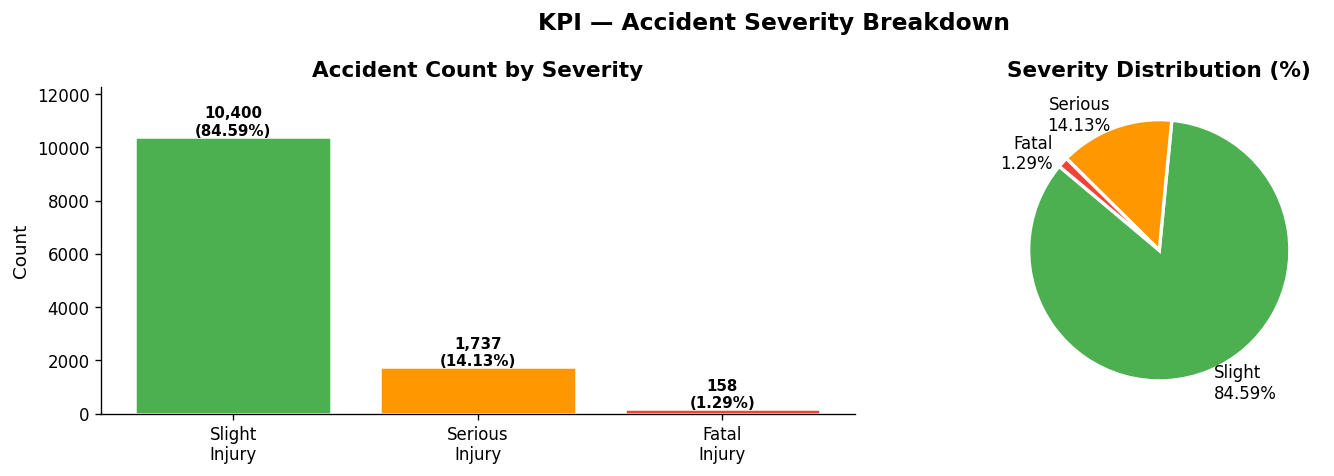

In [ ]:
# ── Fig 1: Severity breakdown bar chart ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sev_names = ['Slight\nInjury', 'Serious\nInjury', 'Fatal\nInjury']
sev_vals  = [slight_count, serious_count, fatal_count]
sev_pcts  = [slight_pct,   serious_pct,   fatal_pct]

bars = axes[0].bar(sev_names, sev_vals, color=PALETTE, edgecolor='white', linewidth=1.5)
for b, v, p in zip(bars, sev_vals, sev_pcts):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 60,
                 f'{v:,}\n({p}%)', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Accident Count by Severity', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(sev_vals) * 1.18)

axes[1].pie(sev_pcts,
            labels=[f'{n}\n{p}%' for n, p in zip(['Slight','Serious','Fatal'], sev_pcts)],
            colors=PALETTE, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Severity Distribution (%)', fontweight='bold')

plt.suptitle('KPI — Accident Severity Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/final/kpi_fig1_severity.png', bbox_inches='tight')
plt.show()

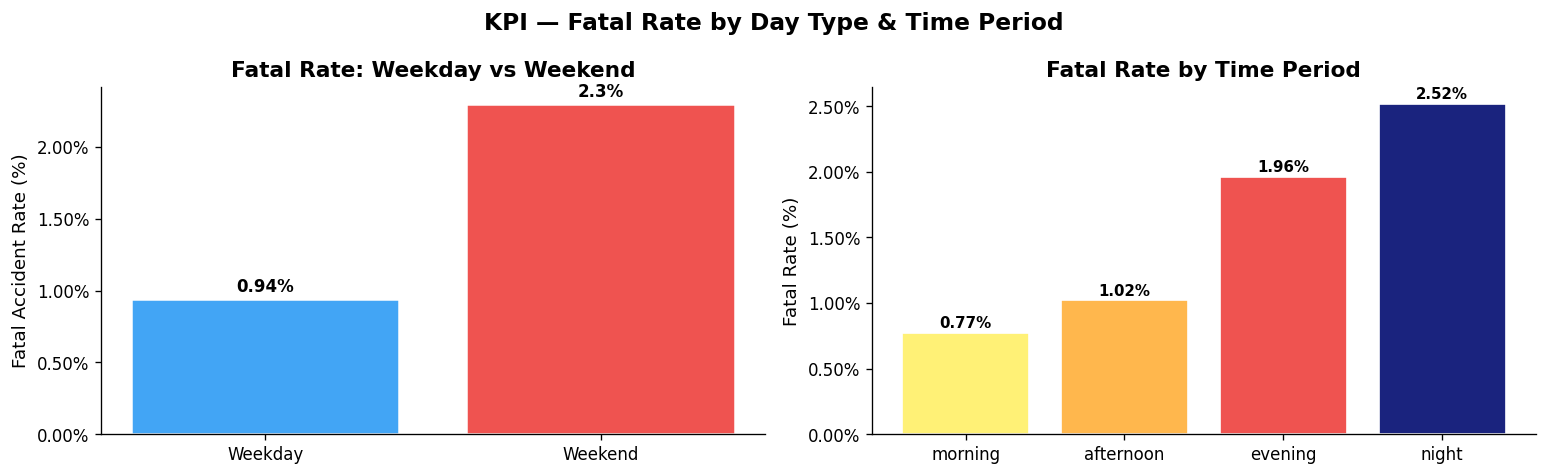

In [ ]:
# ── Fig 2: Fatal rate — Weekend vs Weekday & by Time Period ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Weekend vs Weekday
axes[0].bar(['Weekday', 'Weekend'], [weekday_fatal_rate, weekend_fatal_rate],
            color=['#42A5F5', '#EF5350'], edgecolor='white', linewidth=1.5)
for i, v in enumerate([weekday_fatal_rate, weekend_fatal_rate]):
    axes[0].text(i, v + 0.05, f'{v}%', ha='center', fontweight='bold')
axes[0].set_title('Fatal Rate: Weekday vs Weekend', fontweight='bold')
axes[0].set_ylabel('Fatal Accident Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Fatal rate by time period
time_fatal = df.groupby('time_period')['accident_severity'].apply(
    lambda x: (x.str.lower() == 'fatal injury').mean() * 100
).reindex(['morning', 'afternoon', 'evening', 'night']).round(2)

axes[1].bar(time_fatal.index, time_fatal.values,
            color=['#FFF176', '#FFB74D', '#EF5350', '#1A237E'], edgecolor='white')
for i, v in enumerate(time_fatal.values):
    axes[1].text(i, v + 0.04, f'{v}%', ha='center', fontweight='bold', fontsize=9)
axes[1].set_title('Fatal Rate by Time Period', fontweight='bold')
axes[1].set_ylabel('Fatal Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('KPI — Fatal Rate by Day Type & Time Period', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/final/kpi_fig2_fatal_rates.png', bbox_inches='tight')
plt.show()

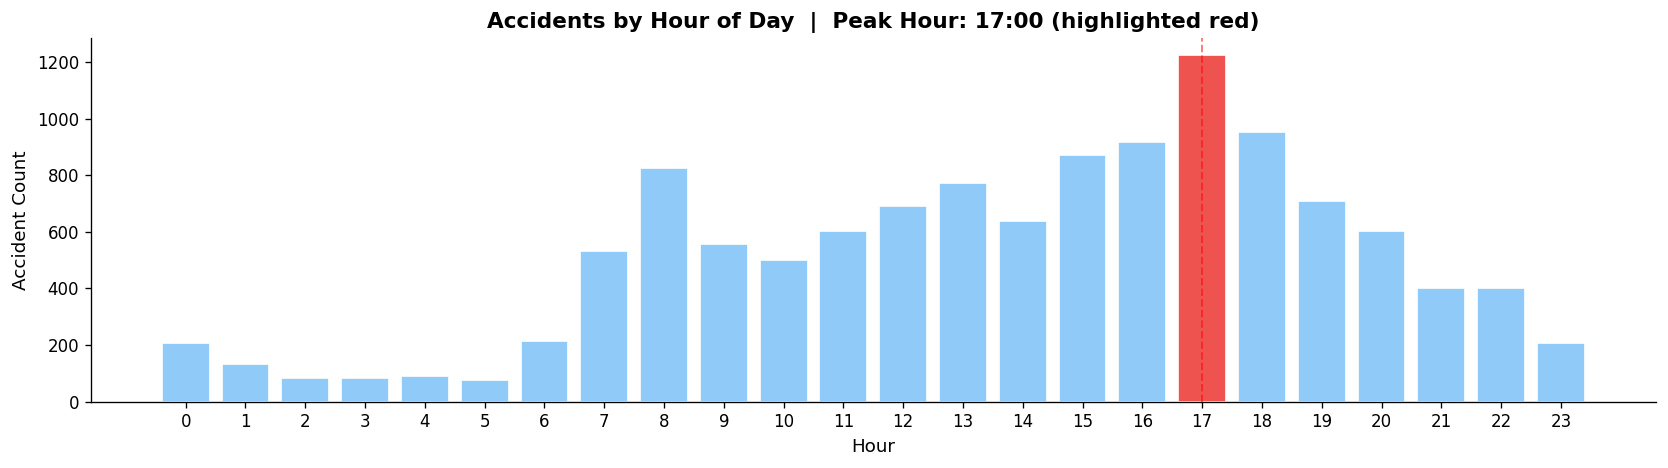

KPI → Peak Hour: 17:00 with 1,224 accidents


In [ ]:
# ── Fig 3: Accidents by hour (KPI — peak hour) ─────────────────────────────────
hourly = df.groupby('hour').size()

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(hourly.index, hourly.values,
              color=['#EF5350' if h == peak_hour else '#90CAF9' for h in hourly.index],
              edgecolor='white')
ax.set_title(f'Accidents by Hour of Day  |  Peak Hour: {peak_hour}:00 (highlighted red)',
             fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Accident Count')
ax.set_xticks(range(0, 24))
ax.axvline(x=peak_hour, color='red', linestyle='--', linewidth=1.2, alpha=0.5)

plt.tight_layout()
plt.savefig('data/final/kpi_fig3_peak_hour.png', bbox_inches='tight')
plt.show()
print(f'KPI → Peak Hour: {peak_hour}:00 with {int(hourly[peak_hour]):,} accidents')

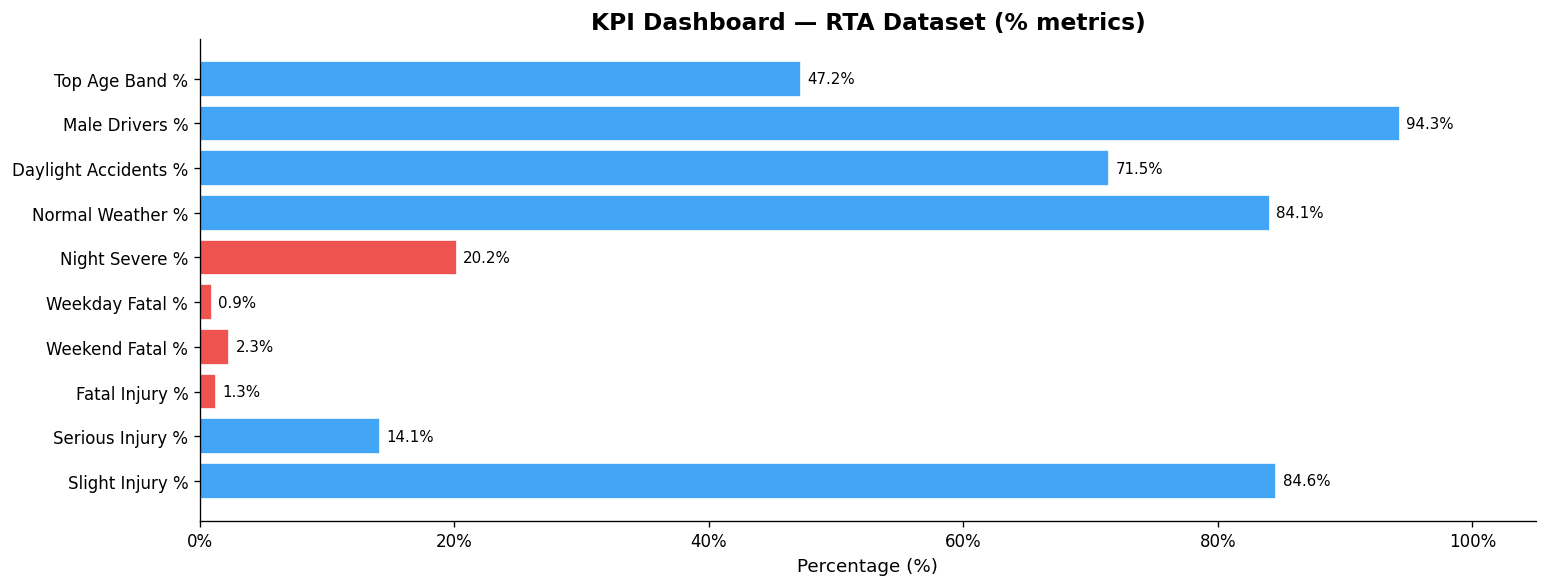

In [ ]:
# ── Fig 4: KPI Dashboard — summary bar chart ───────────────────────────────────
dashboard_kpis = {
    'Slight Injury %':      slight_pct,
    'Serious Injury %':     serious_pct,
    'Fatal Injury %':       fatal_pct,
    'Weekend Fatal %':      weekend_fatal_rate,
    'Weekday Fatal %':      weekday_fatal_rate,
    'Night Severe %':       night_severe_rate,
    'Normal Weather %':     normal_weather_pct,
    'Daylight Accidents %': daylight_pct,
    'Male Drivers %':       male_driver_pct,
    'Top Age Band %':       top_age_band_pct,
}

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#EF5350' if 'Fatal' in k or 'Severe' in k else '#42A5F5' for k in dashboard_kpis]
bars = ax.barh(list(dashboard_kpis.keys()), list(dashboard_kpis.values()),
               color=colors, edgecolor='white')
for b in bars:
    w = b.get_width()
    ax.text(w + 0.5, b.get_y() + b.get_height()/2,
            f'{w:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Percentage (%)')
ax.set_title('KPI Dashboard — RTA Dataset (% metrics)', fontweight='bold', fontsize=14)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 105)

plt.tight_layout()
plt.savefig('data/final/kpi_fig4_dashboard.png', bbox_inches='tight')
plt.show()

---
## 5. Build Final Analytics-Ready Table

In [ ]:
# ── Select and rename final columns ────────────────────────────────────────────
# Only keep columns relevant for analytics / ML
desired_cols = [
    'accident_severity',
    'severity_score',
    'number_of_casualties',
    'hour',
    'time_period',
    'is_weekend',
    'age_band_of_driver',
    'sex_of_driver',
    'driving_experience',
    'type_of_vehicle',
    'type_of_collision',
    'cause_of_accident',
    'weather_conditions',
    'light_conditions',
    'road_surface_conditions',
    'area_accident_occured',
    'types_of_junction',
]

# Keep only columns that actually exist in the dataframe
final_cols = [c for c in desired_cols if c in df.columns]
missing_desired = [c for c in desired_cols if c not in df.columns]
if missing_desired:
    print(f'⚠️  Columns not found (skipped): {missing_desired}')

df_final = df[final_cols].copy()
print(f'Final table shape: {df_final.shape}')
df_final.head(3)

Final table shape: (12295, 17)


,accident_severity,severity_score,number_of_casualties,hour,time_period,is_weekend,age_band_of_driver,sex_of_driver,driving_experience,type_of_vehicle,type_of_collision,cause_of_accident,weather_conditions,light_conditions,road_surface_conditions,area_accident_occured,types_of_junction
0,slight injury,1,2,17,afternoon,False,18-30,male,1-2yr,automobile,collision with roadside-parked vehicles,moving backward,normal,daylight,dry,residential areas,no junction
1,slight injury,1,2,17,afternoon,False,31-50,male,above 10yr,public (> 45 seats),vehicle with vehicle collision,overtaking,normal,daylight,dry,office areas,no junction
2,serious injury,2,2,17,afternoon,False,18-30,male,1-2yr,lorry (41?100q),collision with roadside objects,changing lane to the left,normal,daylight,dry,recreational areas,no junction


In [ ]:
# ── Enforce final dtypes ───────────────────────────────────────────────────────
int_cols    = ['severity_score', 'number_of_casualties', 'hour', 'is_weekend']
str_cols    = ['accident_severity', 'day_name', 'time_period', 'age_band_of_driver',
               'sex_of_driver', 'driving_experience', 'type_of_vehicle',
               'type_of_collision', 'cause_of_accident', 'weather_conditions',
               'light_conditions', 'road_surface_conditions',
               'area_accident_occured', 'types_of_junction']

for col in int_cols:
    if col in df_final.columns:
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce').astype('Int64')

for col in str_cols:
    if col in df_final.columns:
        df_final[col] = df_final[col].astype(str).str.strip().str.lower()

print('Dtypes enforced ✓')
print(df_final.dtypes)

Dtypes enforced ✓
accident_severity          object
severity_score              Int64
number_of_casualties        Int64
hour                        Int64
time_period                object
is_weekend                  Int64
age_band_of_driver         object
sex_of_driver              object
driving_experience         object
type_of_vehicle            object
type_of_collision          object
cause_of_accident          object
weather_conditions         object
light_conditions           object
road_surface_conditions    object
area_accident_occured      object
types_of_junction          object
dtype: object


In [ ]:
# ── Add metadata columns ───────────────────────────────────────────────────────
df_final['load_timestamp']   = LOAD_TIMESTAMP
df_final['pipeline_version'] = PIPELINE_VER
df_final['source_file']      = 'cleaned_rta.csv'

# ── Reset index ────────────────────────────────────────────────────────────────
df_final = df_final.reset_index(drop=True)

print('Metadata columns added.')
print('Final shape:', df_final.shape)
df_final.tail(3)

Metadata columns added.
Final shape: (12295, 20)


,accident_severity,severity_score,number_of_casualties,hour,time_period,is_weekend,age_band_of_driver,sex_of_driver,driving_experience,type_of_vehicle,type_of_collision,cause_of_accident,weather_conditions,light_conditions,road_surface_conditions,area_accident_occured,types_of_junction,load_timestamp,pipeline_version,source_file
12292,serious injury,2,1,13,afternoon,1,over 51,male,5-10yr,bajaj,vehicle with vehicle collision,changing lane to the right,normal,daylight,dry,outside rural areas,no junction,2026-04-21 14:37:11,v1.0,cleaned_rta.csv
12293,slight injury,1,1,13,afternoon,1,18-30,female,above 10yr,lorry (41?100q),vehicle with vehicle collision,driving under the influence of drugs,normal,darkness - lights lit,dry,office areas,no junction,2026-04-21 14:37:11,v1.0,cleaned_rta.csv
12294,slight injury,1,1,13,afternoon,1,18-30,male,5-10yr,other,vehicle with vehicle collision,changing lane to the right,normal,darkness - lights lit,dry,outside rural areas,o shape,2026-04-21 14:37:11,v1.0,cleaned_rta.csv


In [ ]:
# ── Final assertions before save ───────────────────────────────────────────────
critical_cols = ['accident_severity', 'severity_score', 'number_of_casualties']
for col in critical_cols:
    if col in df_final.columns:
        null_count = df_final[col].isna().sum()
        assert null_count == 0, f"CRITICAL: '{col}' has {null_count} nulls — aborting!"

assert len(df_final) > 0, 'Final dataframe is empty!'
print('All assertions passed ✓ — data is ready for load.')

All assertions passed ✓ — data is ready for load.


---
## 6. Save Final Outputs

In [ ]:
# ── Save CSV ───────────────────────────────────────────────────────────────────
csv_path = 'data/final/final_output.csv'
df_final.to_csv(csv_path, index=False)
csv_size = os.path.getsize(csv_path) / 1024

# ── Save Parquet ───────────────────────────────────────────────────────────────
parquet_path = 'data/final/final_output.parquet'
df_final.to_parquet(parquet_path, index=False)
parquet_size = os.path.getsize(parquet_path) / 1024

print('='*55)
print('           FINAL LOAD REPORT')
print('='*55)
print(f'  Load Timestamp    : {LOAD_TIMESTAMP}')
print(f'  Pipeline Version  : {PIPELINE_VER}')
print(f'  Records Loaded    : {len(df_final):,}')
print(f'  Columns           : {len(df_final.columns)}')
print(f'  CSV  → {csv_path}  ({csv_size:.1f} KB)')
print(f'  PKT  → {parquet_path}  ({parquet_size:.1f} KB)')
print(f'  KPIs → data/final/kpi_summary.csv  ({len(kpi_df)} KPIs)')
print('='*55)
print('✅ Pipeline complete — all files saved to data/final/')

           FINAL LOAD REPORT
  Load Timestamp    : 2026-04-21 14:37:11
  Pipeline Version  : v1.0
  Records Loaded    : 12,295
  Columns           : 20
  CSV  → data/final/final_output.csv  (2431.7 KB)
  PKT  → data/final/final_output.parquet  (62.5 KB)
  KPIs → data/final/kpi_summary.csv  (32 KPIs)
✅ Pipeline complete — all files saved to data/final/


---
## 7. Grouped Aggregation Tables (for reporting)
These tables summarise KPIs by key dimensions and can be exported for dashboards.

In [ ]:
# ── Severity by time period ────────────────────────────────────────────────────
time_period_summary = df_final.groupby('time_period').agg(
    total_accidents    = ('accident_severity', 'count'),
    total_casualties   = ('number_of_casualties', 'sum'),
    avg_casualties     = ('number_of_casualties', 'mean'),
    avg_severity_score = ('severity_score', 'mean'),
    fatal_count        = ('accident_severity', lambda x: (x == 'fatal injury').sum()),
    serious_count      = ('accident_severity', lambda x: (x == 'serious injury').sum()),
).round(3)
time_period_summary['fatal_rate_%'] = (
    time_period_summary['fatal_count'] / time_period_summary['total_accidents'] * 100
).round(2)

print('=== Severity by Time Period ===')
display(time_period_summary)
time_period_summary.to_csv('data/final/agg_by_time_period.csv')

=== Severity by Time Period ===


,total_accidents,total_casualties,avg_casualties,avg_severity_score,fatal_count,serious_count,fatal_rate_%
time_period,,,,,,,
afternoon,5116,7925,1.549,1.154,52,682,1.02
evening,3273,5397,1.649,1.195,64,510,1.96
morning,3232,4528,1.401,1.147,25,426,0.77
night,674,1185,1.758,1.227,17,119,2.52


In [ ]:
# ── Severity by cause of accident ─────────────────────────────────────────────
cause_summary = df_final.groupby('cause_of_accident').agg(
    total_accidents    = ('accident_severity', 'count'),
    total_casualties   = ('number_of_casualties', 'sum'),
    avg_severity_score = ('severity_score', 'mean'),
    fatal_count        = ('accident_severity', lambda x: (x == 'fatal injury').sum()),
).round(3)
cause_summary['fatal_rate_%'] = (
    cause_summary['fatal_count'] / cause_summary['total_accidents'] * 100
).round(2)
cause_summary = cause_summary.sort_values('total_accidents', ascending=False)

print('=== Top Causes of Accident ===')
display(cause_summary.head(10))
cause_summary.to_csv('data/final/agg_by_cause.csv')

=== Top Causes of Accident ===


,total_accidents,total_casualties,avg_severity_score,fatal_count,fatal_rate_%
cause_of_accident,,,,,
no distancing,2283,3490,1.151,20,0.88
changing lane to the right,1802,2836,1.168,23,1.28
changing lane to the left,1471,2346,1.162,16,1.09
driving carelessly,1402,2160,1.18,22,1.57
no priority to vehicle,1205,1883,1.144,13,1.08
moving backward,1137,1748,1.188,26,2.29
no priority to pedestrian,720,1041,1.146,5,0.69
other,456,720,1.171,7,1.54
overtaking,429,659,1.193,4,0.93


In [ ]:
# ── Severity by age band ──────────────────────────────────────────────────────
age_summary = df_final.groupby('age_band_of_driver').agg(
    total_accidents    = ('accident_severity', 'count'),
    avg_casualties     = ('number_of_casualties', 'mean'),
    avg_severity_score = ('severity_score', 'mean'),
    fatal_count        = ('accident_severity', lambda x: (x == 'fatal injury').sum()),
).round(3)
age_summary['fatal_rate_%'] = (
    age_summary['fatal_count'] / age_summary['total_accidents'] * 100
).round(2)

print('=== Severity by Driver Age Band ===')
display(age_summary)
age_summary.to_csv('data/final/agg_by_age_band.csv')

=== Severity by Driver Age Band ===


,total_accidents,avg_casualties,avg_severity_score,fatal_count,fatal_rate_%
age_band_of_driver,,,,,
18-30,5806,1.502,1.157,68,1.17
31-50,4083,1.566,1.158,54,1.32
over 51,1584,1.593,1.192,24,1.52
under 18,822,1.697,1.235,12,1.46


---
## 8. etl_pipeline.py Integration Helper
Run this cell to auto-generate the function signature for `scripts/etl_pipeline.py`

In [ ]:
pipeline_code = '''
# ─── scripts/etl_pipeline.py  (Step 5: Final Load) ────────────────────────────

import pandas as pd
import numpy as np
import os
from datetime import datetime

def run_final_load(input_path: str = "cleaned_rta.csv",
                   output_dir: str = "data/final",
                   original_row_count: int = 12316) -> dict:
    """
    Step 5 of the RTA ETL pipeline.
    Computes all KPIs and saves the final analytics-ready dataset.

    Parameters
    ----------
    input_path        : path to cleaned CSV from notebook 02
    output_dir        : directory to write final outputs
    original_row_count: row count before cleaning (for quality KPIs)

    Returns
    -------
    dict with all computed KPI values
    """
    os.makedirs(output_dir, exist_ok=True)
    df = pd.read_csv(input_path)
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

    # --- KPIs ---
    total_records      = len(df)
    total_casualties   = int(df["number_of_casualties"].sum())
    sev_counts         = df["accident_severity"].str.lower().value_counts()
    fatal_pct          = round(sev_counts.get("fatal injury", 0) / total_records * 100, 2)
    serious_pct        = round(sev_counts.get("serious injury", 0) / total_records * 100, 2)
    slight_pct         = round(sev_counts.get("slight injury", 0) / total_records * 100, 2)
    peak_hour          = int(df["hour"].value_counts().idxmax())
    weekend_fatal_rate = round((df[df["is_weekend"]==1]["accident_severity"].str.lower()=="fatal injury").mean()*100, 2)
    weekday_fatal_rate = round((df[df["is_weekend"]==0]["accident_severity"].str.lower()=="fatal injury").mean()*100, 2)
    rows_retained_pct  = round(total_records / original_row_count * 100, 2)

    kpis = {
        "total_records": total_records,
        "total_casualties": total_casualties,
        "slight_pct": slight_pct,
        "serious_pct": serious_pct,
        "fatal_pct": fatal_pct,
        "peak_hour": peak_hour,
        "weekend_fatal_rate": weekend_fatal_rate,
        "weekday_fatal_rate": weekday_fatal_rate,
        "rows_retained_pct": rows_retained_pct,
    }

    # --- Save outputs ---
    df.to_csv(f"{output_dir}/final_output.csv", index=False)
    df.to_parquet(f"{output_dir}/final_output.parquet", index=False)
    pd.DataFrame(kpis.items(), columns=["KPI","Value"]).to_csv(f"{output_dir}/kpi_summary.csv", index=False)

    print(f"[ETL Step 5] Complete. {total_records:,} records saved to {output_dir}/")
    return kpis


if __name__ == "__main__":
    kpis = run_final_load()
    print(kpis)
'''

print(pipeline_code)


# ─── scripts/etl_pipeline.py  (Step 5: Final Load) ────────────────────────────

import pandas as pd
import numpy as np
import os
from datetime import datetime

def run_final_load(input_path: str = "cleaned_rta.csv",
                   output_dir: str = "data/final",
                   original_row_count: int = 12316) -> dict:
    """
    Step 5 of the RTA ETL pipeline.
    Computes all KPIs and saves the final analytics-ready dataset.

    Parameters
    ----------
    input_path        : path to cleaned CSV from notebook 02
    output_dir        : directory to write final outputs
    original_row_count: row count before cleaning (for quality KPIs)

    Returns
    -------
    dict with all computed KPI values
    """
    os.makedirs(output_dir, exist_ok=True)
    df = pd.read_csv(input_path)
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

    # --- KPIs ---
    total_records      = len(df)
    total_casualties   = int(df["number_of_casualties"].sum())
   

---
# ✅ Summary

| Output File | Description |
|---|---|
| `data/final/final_output.csv` | Analytics-ready dataset (all cleaned rows + metadata) |
| `data/final/final_output.parquet` | Same, in Parquet format for efficient load |
| `data/final/kpi_summary.csv` | All 31 computed KPIs |
| `data/final/agg_by_time_period.csv` | Grouped aggregation by time period |
| `data/final/agg_by_cause.csv` | Grouped aggregation by cause of accident |
| `data/final/agg_by_age_band.csv` | Grouped aggregation by driver age band |
| `data/final/kpi_fig1_severity.png` | Severity breakdown chart |
| `data/final/kpi_fig2_fatal_rates.png` | Fatal rates chart |
| `data/final/kpi_fig3_peak_hour.png` | Peak hour chart |
| `data/final/kpi_fig4_dashboard.png` | KPI dashboard chart |